In [1]:
from matplotlib.backends.backend_pdf import PdfPages

#Basic Setup
import matplotlib.pyplot as plt
import numpy as np
import uproot
import pandas as pd
import matplotlib.ticker as mticker
import math
#open root file


#df = uproot.open(
 #   "/volatile/clas12/cooperb/SULI/pid_training_test.root:PhysicsEvents"
#).arrays(library="pd")
cols = ["pid", "p", "theta", "beta", "chi2pid", "rich_RQ", "vz", "sector", "phi"]

#cols = ["mc_matching_pid","ftof_energy_1A", "ftof_energy_1B", "ftof_time_1A", "ftof_time_1B", "ftof_path_1A", "ftof_path_1B", "ecin_energy", "ecout_energy", "ecin_time", "ecout_time", "ecin_path", "ecout_path", "nphe_htcc"]

df = uproot.open("/volatile/clas12/cooperb/SULI/pid_training_v2.root:PhysicsEvents").arrays(cols, library="pd")
real =uproot.open("/volatile/clas12/cooperb/SULI/data_pid_training_test.root:PhysicsEvents").arrays(cols, library="pd")
#creates a list of matching events (excludes events that failed matching)
#matched = df[df["mc_matching_pid"] != -9999].copy()
#baseline = matched[(matched["p"]>=1)&(matched["p"]<=5)&(matched["mc_matching_pid"]==321)&passes_kplus_chi2pid_cut(matched["chi2pid"], matched["p"])]
#baseline = matched[(matched["p"]>=1)&(matched["p"]<=5)&(abs(matched["chi2pid"])<1)]
direct = "/work/clas12/CooperBe/Argonne2026/suli2026_pid/figures/audit/subtract/group1/"  #path directory for saving pngs :)
#matched=baseline

#matched = matched[(matched["nphe_htcc"]!=-9999)&(matched["nphe_htcc"]!=0)]
#print("ftof_path_1A:  ", matched["nphe_htcc"].describe())
#print("\nQuick eyeball:")
#print(f"  ftof_time_1A range: [{matched['nphe_htcc'].min():.2f}, {matched['nphe_htcc'].max():.2f}]")

allPlots=[]

In [2]:
ranges=[
[-2212, 2212], #pid
[0.5, 5],    #p
[4, 44], #theta
[0, 1],  #beta  
[-10, 10], #chi2pid
[0,1], #rich_RQ
[0,0.6], #Vz (Real data has hard cut a 0.6
[0, 6], #sector
[0,360]  #Phi  
]    

parts = [321, 211, 2212]
colors= ["Red", "Blue"]
labels=["Data", "Monte-Carlo"]

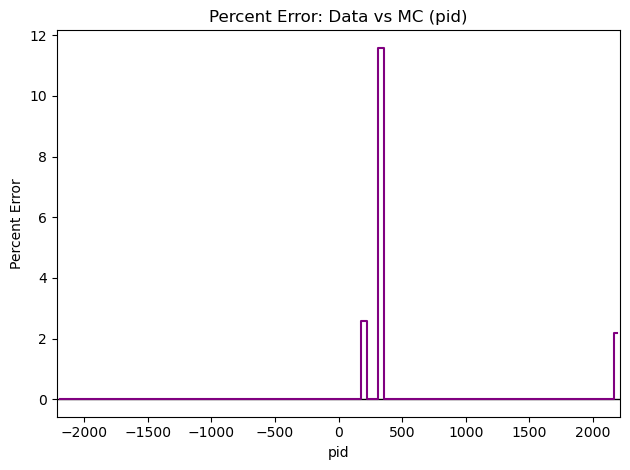

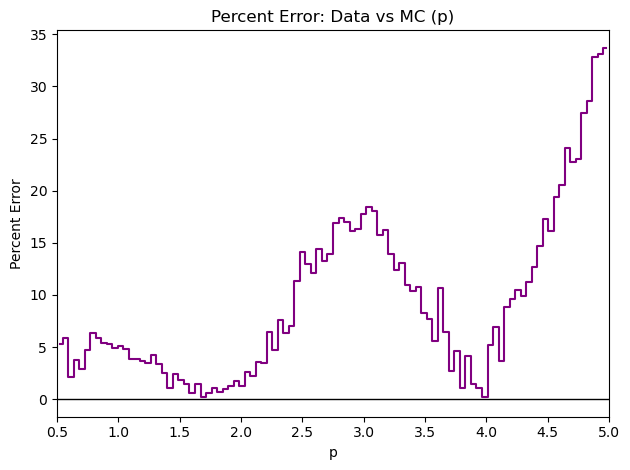

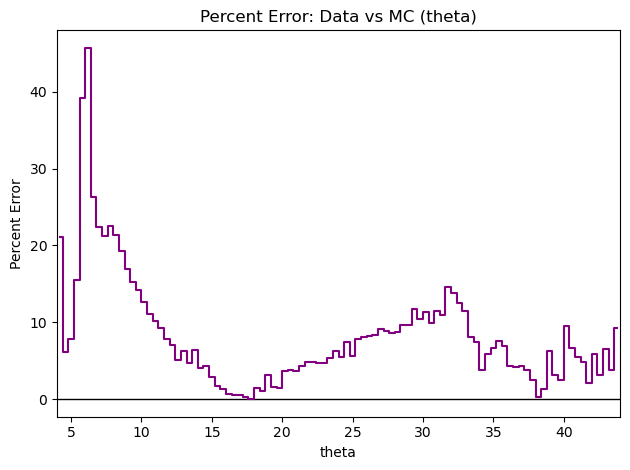

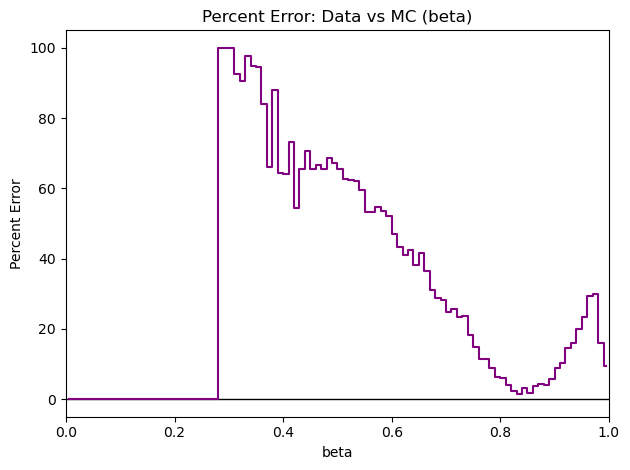

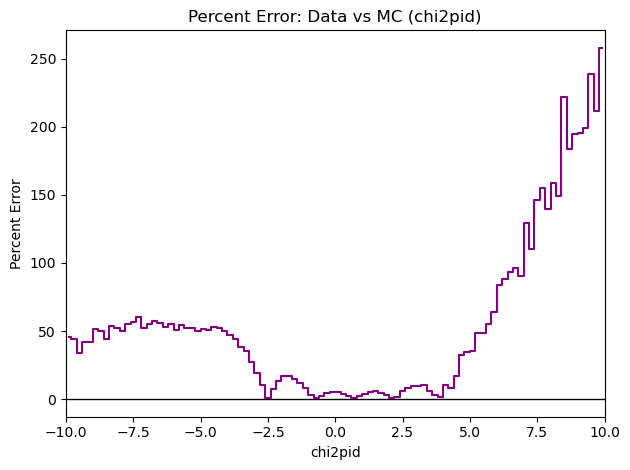

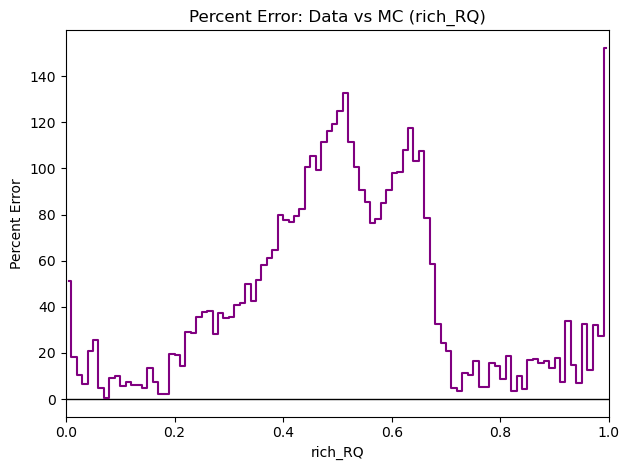

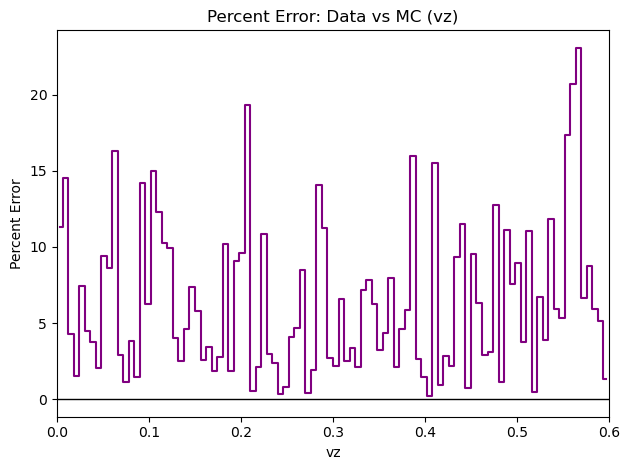

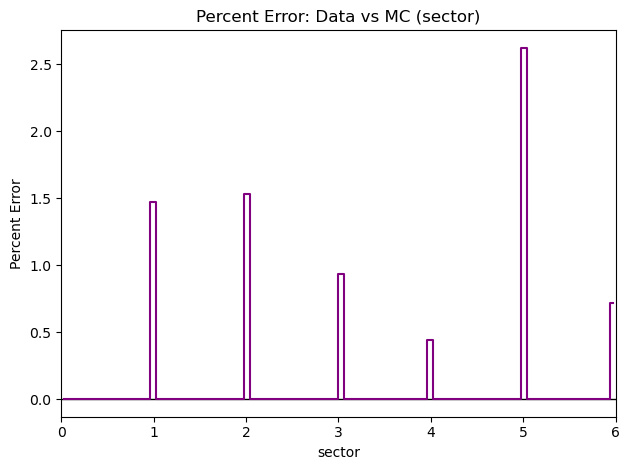

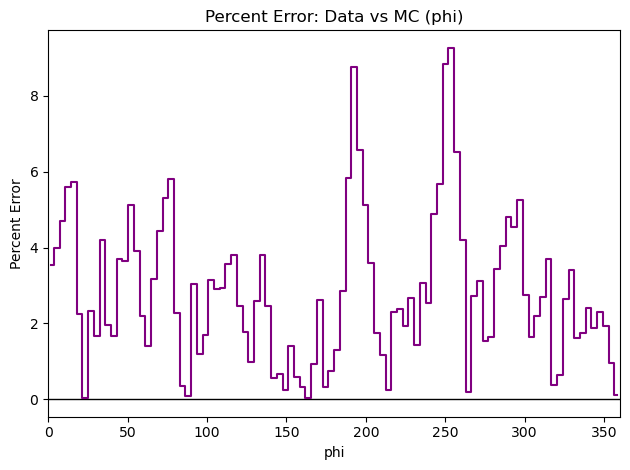

/scratch/slurm/5044522/.cache/tmp/ipykernel_2768158/2961564485.py:2: MatplotlibDeprecationWarning: Keeping empty pdf files is deprecated since 3.8 and support will be removed in 3.10.
  with PdfPages("/work/clas12/CooperBe/Argonne2026/suli2026_pid/figures/audit/subtract/" + "AllPlots.pdf") as pdf:


In [3]:
cnt = 0
with PdfPages("/work/clas12/CooperBe/Argonne2026/suli2026_pid/figures/audit/subtract/" + "AllPlots.pdf") as pdf:
    for varbs in cols:

        real_data = real[real[varbs] != -9999]
        mc_data = df[df[varbs] != -9999]

        rng = (ranges[cnt][0], ranges[cnt][1])
        bins = 100

    # --- histogram (normalized) ---
        real_hist, edges = np.histogram(
            real_data[varbs],
            bins=bins,
            range=rng,
            density=True
        )

        mc_hist, _ = np.histogram(
            mc_data[varbs],
            bins=bins,
            range=rng,
            density=True
        )

        #percent error
        mask = real_hist != 0
        percent_err = np.zeros_like(real_hist)
        percent_err[mask] = abs(((real_hist[mask] - mc_hist[mask]) / real_hist[mask]) * 100)

        centers = 0.5 * (edges[:-1] + edges[1:])

    #plot
        fig, ax = plt.subplots()

        ax.axhline(0, color="black", linewidth=1)
        ax.step(centers, percent_err, where="mid", color="purple")

        ax.set_xlabel(varbs)
        ax.set_ylabel("Percent Error")
        ax.set_title(f"Percent Error: Data vs MC ({varbs})")

        ax.set_xlim(rng)

        fig.tight_layout()
        fig.savefig(direct + varbs + "Difference.png", dpi=150)
        
        plt.show()
        allPlots.append(fig)
        plt.close(fig)

        cnt += 1

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import uproot
import pandas as pd
import matplotlib.ticker as mticker
import math

#cols = ["pid", "mc_matching_pid", "p", "theta", "beta", "chi2pid", "rich_RQ", "vz", "sector", "phi"]
cols = ["pid","ftof_energy_1A", "ftof_energy_1B", "ftof_time_1A", "ftof_time_1B", "ftof_path_1A", "ftof_path_1B", "ecin_energy", "ecout_energy", "ecin_time", "ecout_time", "ecin_path", "ecout_path", "nphe_htcc"]

df = uproot.open("/volatile/clas12/cooperb/SULI/pid_training_v2.root:PhysicsEvents").arrays(cols, library="pd")
real =uproot.open("/volatile/clas12/cooperb/SULI/data_pid_training_test.root:PhysicsEvents").arrays(cols, library="pd")
#creates a list of matching events (excludes events that failed matching)

In [5]:
ranges=[
[-2212,2212], #pid
[0, 25],    #ftof_energy_1A
[0, 25], #ftof_energy_1B
[20, 50],  # ftof_time_1A
[20, 50], #ftof_time_1B
[600,800], #ftof_path_1A
[600,800], #ftof_path_1B
[0, 1], #ecin_energy
[0,1],  #ecout_energy
[20,50], #ecin_time 
[20,50], #ecout_time 
[733,800], #ecin_path
[733,800], #ecout_path
[1,16] #nphe_htcc    
]    
direct = "/work/clas12/CooperBe/Argonne2026/suli2026_pid/figures/audit/subtract/group2/"  #path directory for saving pngs :)

colors= ["Red", "Blue"]
labels=["Data", "Monte-Carlo"]

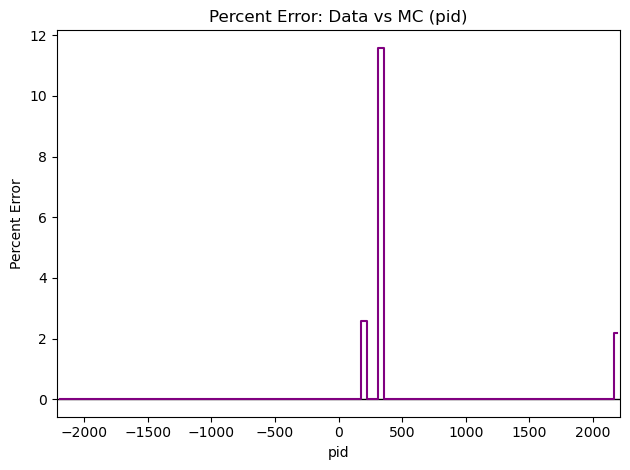

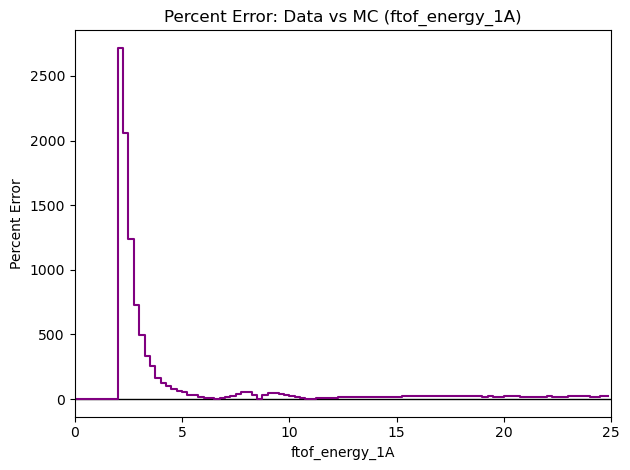

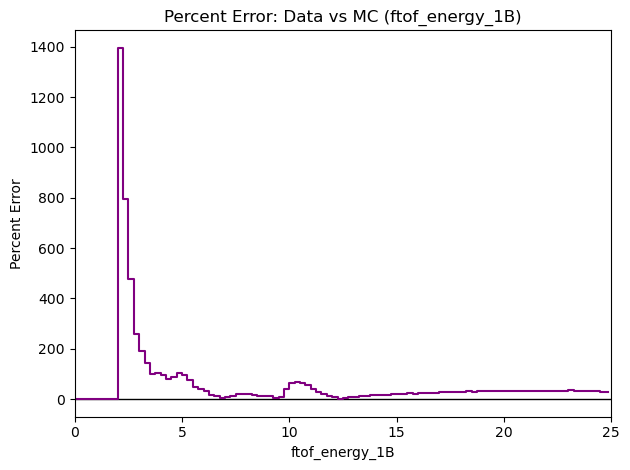

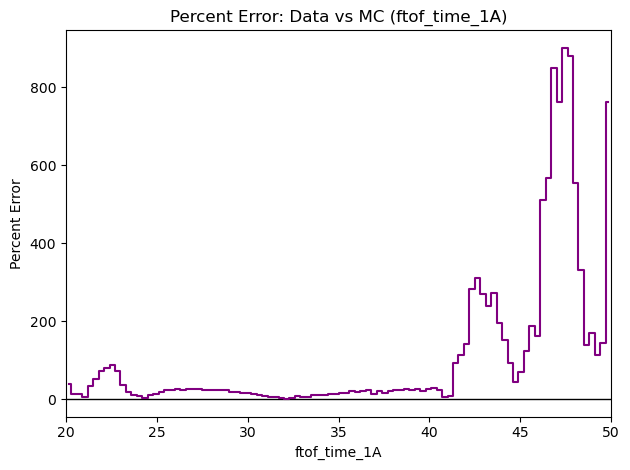

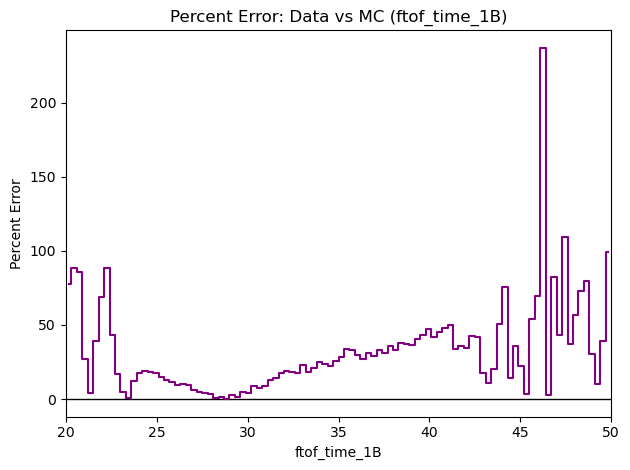

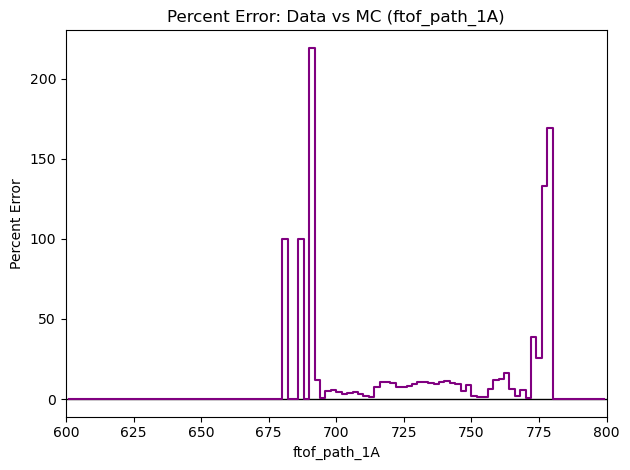

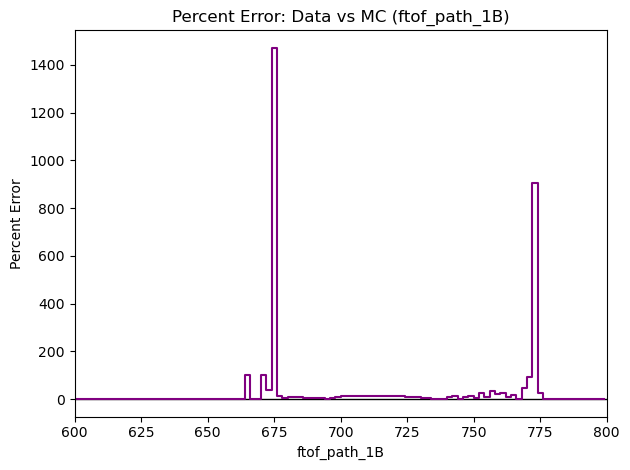

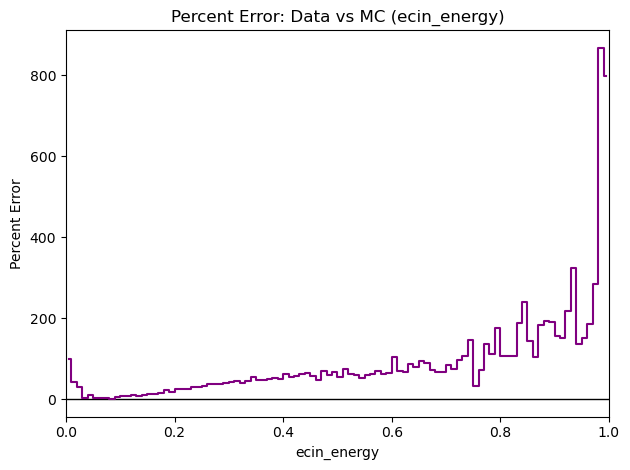

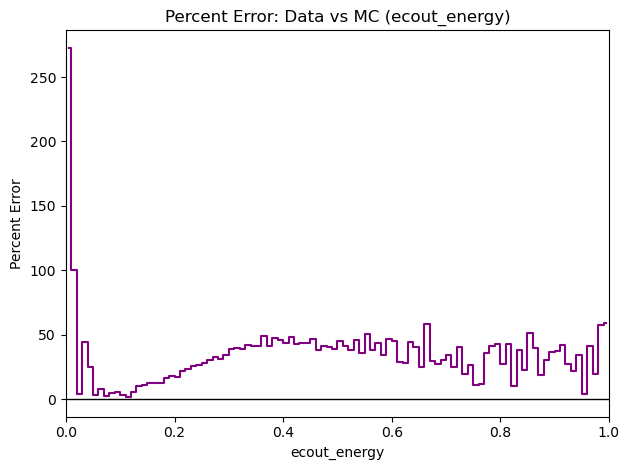

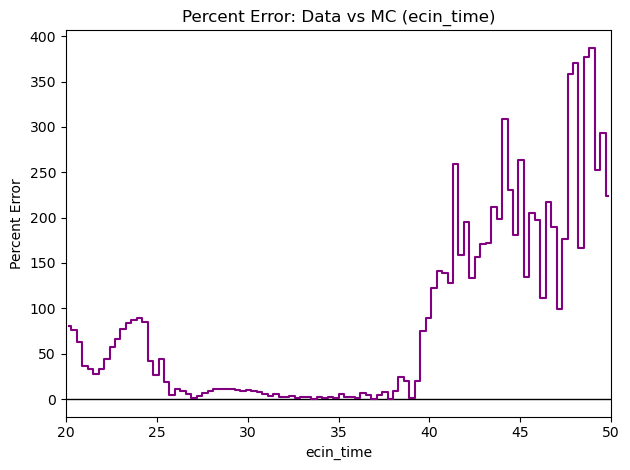

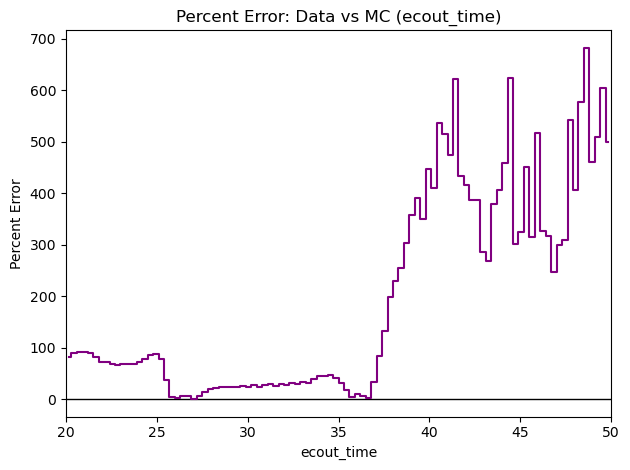

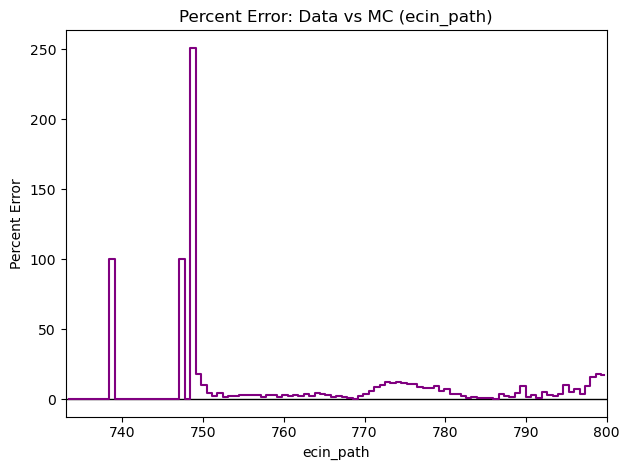

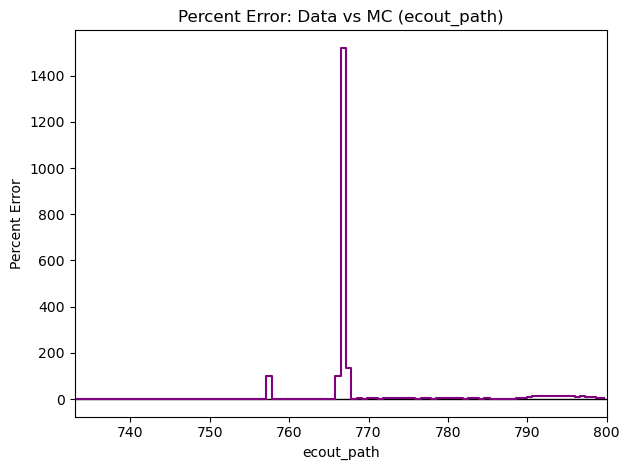

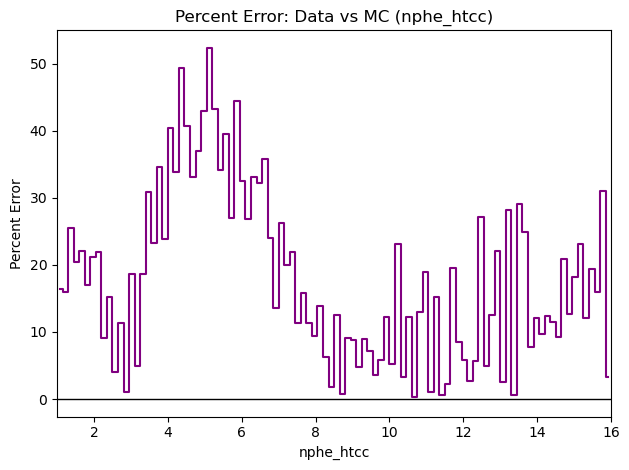

In [6]:
cnt = 0
with PdfPages("/work/clas12/CooperBe/Argonne2026/suli2026_pid/figures/audit/subtract/" + "AllPlots.pdf") as pdf:
    for varbs in cols:

        real_data = real[real[varbs] != -9999]
        mc_data = df[df[varbs] != -9999]

        rng = (ranges[cnt][0], ranges[cnt][1])
        bins = 100

    # --- histogram (normalized) ---
        real_hist, edges = np.histogram(
            real_data[varbs],
            bins=bins,
            range=rng,
            density=True
        )

        mc_hist, _ = np.histogram(
            mc_data[varbs],
            bins=bins,
            range=rng,
            density=True
        )

        #percent error
        mask = real_hist != 0
        percent_err = np.zeros_like(real_hist)
        percent_err[mask] = abs(((real_hist[mask] - mc_hist[mask]) / real_hist[mask]) * 100)

        centers = 0.5 * (edges[:-1] + edges[1:])

    #plot
        fig, ax = plt.subplots()

        ax.axhline(0, color="black", linewidth=1)
        ax.step(centers, percent_err, where="mid", color="purple")

        ax.set_xlabel(varbs)
        ax.set_ylabel("Percent Error")
        ax.set_title(f"Percent Error: Data vs MC ({varbs})")

        ax.set_xlim(rng)

        fig.tight_layout()
        fig.savefig(direct + varbs + "Difference.png", dpi=150)
        pdf.savefig(fig)
        plt.show()
        allPlots.append(fig)
        plt.close(fig)

        cnt += 1

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import uproot
import pandas as pd
import matplotlib.ticker as mticker
import math

#cols = ["pid", "mc_matching_pid", "p", "theta", "beta", "chi2pid", "rich_RQ", "vz", "sector", "phi"]
#cols = ["pid","mc_matching_pid","ftof_energy_1A", "ftof_energy_1B", "ftof_time_1A", "ftof_time_1B", "ftof_path_1A", "ftof_path_1B", "ecin_energy", "ecout_energy", "ecin_time", "ecout_time", "ecin_path", "ecout_path", "nphe_htcc"]
cols =["pid","pcal_energy","pcal_time","pcal_path", "ftof_energy_2", "ftof_time_2", "ftof_path_2"]
df = uproot.open("/volatile/clas12/cooperb/SULI/pid_training_v2.root:PhysicsEvents").arrays(cols, library="pd")
real=uproot.open("/volatile/clas12/cooperb/SULI/data_pid_training_test.root:PhysicsEvents").arrays(cols, library="pd")
#creates a list of matching events (excludes events that failed matching)

In [8]:
ranges=[
[-2212, 2212], #pid
[0, 0.9],    #pcal_energy
[20, 50], #pcal_time
[700, 800],  # pcal_path
[0, 16], #ftof_energy_2
[20,50], #ftof_time_2
[600,800] #ftof_path_2
]    
direct = "/work/clas12/CooperBe/Argonne2026/suli2026_pid/figures/audit/subtract/group3/"  #path directory for saving pngs :)

colors= ["Red", "Blue"]
labels=["Data", "Monte-Carlo"]

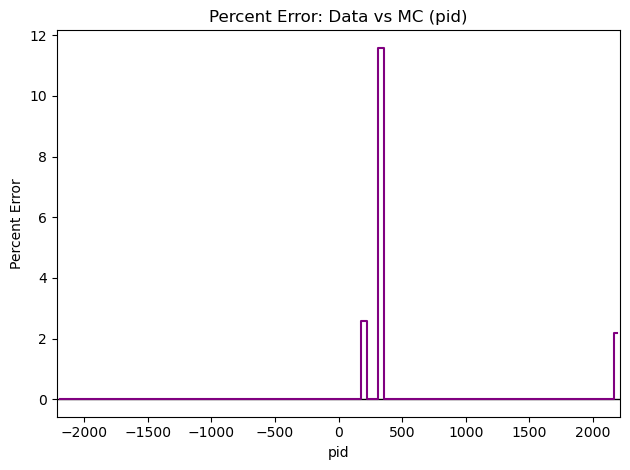

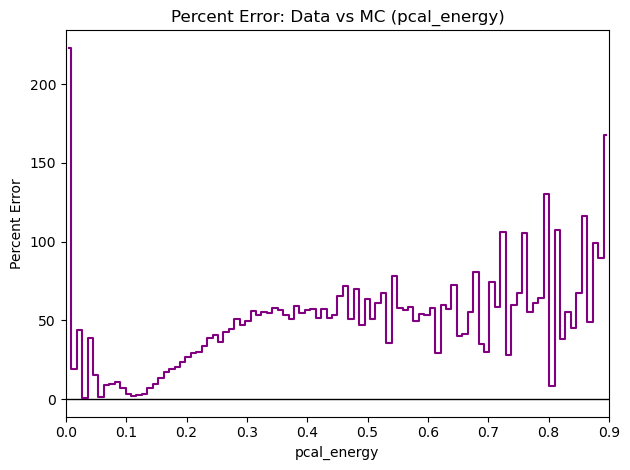

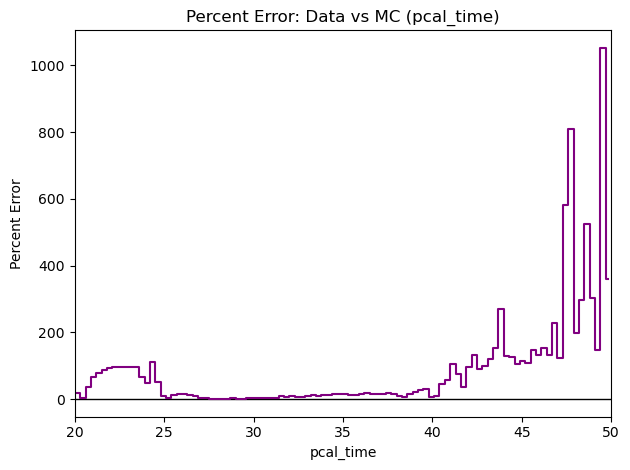

/scratch/slurm/5044522/.cache/tmp/ipykernel_2768158/19708527.py:29: RuntimeWarning: divide by zero encountered in divide
  percent_err[mask] = abs(((real_hist[mask] - mc_hist[mask]) / real_hist[mask]) * 100)


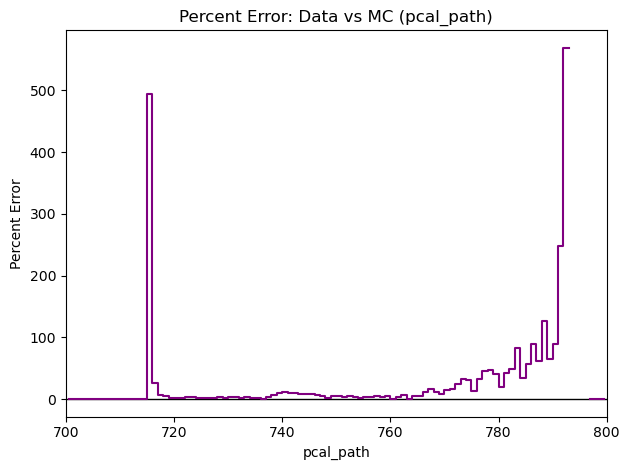

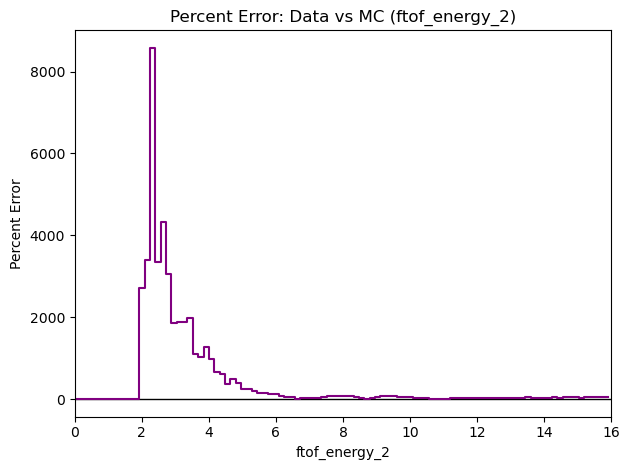

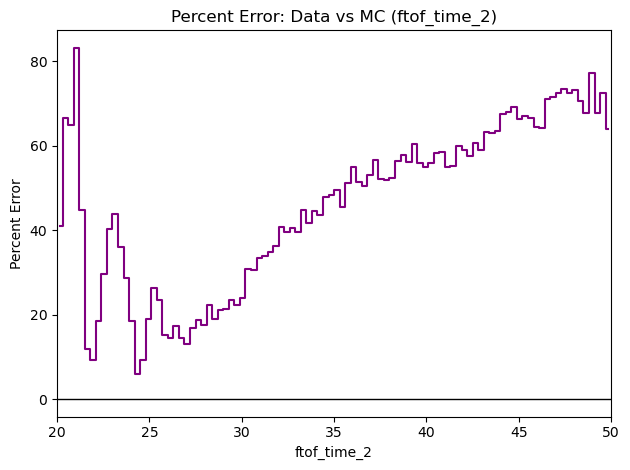

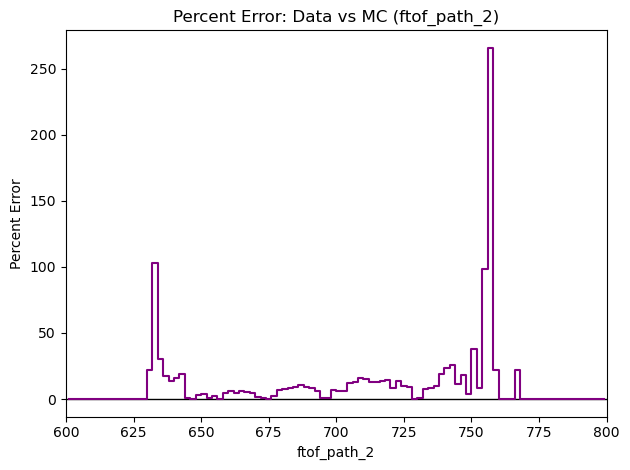

In [9]:
cnt = 0

for varbs in cols:

    real_data = real[real[varbs] != -9999]
    mc_data = df[df[varbs] != -9999]

    rng = (ranges[cnt][0], ranges[cnt][1])
    bins = 100

    # --- histogram (normalized) ---
    real_hist, edges = np.histogram(
        real_data[varbs],
        bins=bins,
        range=rng,
        density=True
    )

    mc_hist, _ = np.histogram(
        mc_data[varbs],
        bins=bins,
        range=rng,
        density=True
    )

    #percent error
    mask = mc_hist != 0
    percent_err = np.zeros_like(real_hist)
    percent_err[mask] = abs(((real_hist[mask] - mc_hist[mask]) / real_hist[mask]) * 100)

    centers = 0.5 * (edges[:-1] + edges[1:])

    #plot
    fig, ax = plt.subplots()

    ax.axhline(0, color="black", linewidth=1)
    ax.step(centers, percent_err, where="mid", color="purple")

    ax.set_xlabel(varbs)
    ax.set_ylabel("Percent Error")
    ax.set_title(f"Percent Error: Data vs MC ({varbs})")

    ax.set_xlim(rng)

    fig.tight_layout()
    fig.savefig(direct + varbs + "Difference.png", dpi=150)
    plt.show()
    allPlots.append(fig)
    plt.close(fig)

    cnt += 1

In [10]:
with PdfPages("/work/clas12/CooperBe/Argonne2026/suli2026_pid/figures/audit/subtract/" + "AllPlotsDifference.pdf") as pdf:
    for plot in allPlots:
        pdf.savefig(plot)